In [25]:
import numpy as np
import pandas as pd
from scipy.special import expit  # Sigmoid
from scipy.stats import norm
np.random.seed(42)

N = 10000

# -------------------------
# 1️⃣ AGE (Normal 40,12)
# -------------------------
age = np.clip(np.random.normal(40, 12, N), 18, 70)

# -------------------------
# 2️⃣ INCOME (Log-normal)
# -------------------------
income = np.random.lognormal(mean=13, sigma=0.5, size=N)
income = np.clip(income, 200000, 5000000)

# -------------------------
# 3️⃣ PORTFOLIO (Correlated with income)
# -------------------------
portfolio_noise = np.random.lognormal(mean=12, sigma=0.6, size=N)
portfolio_value = 0.5 * income + 0.5 * portfolio_noise
portfolio_value = np.clip(portfolio_value, 50000, 10000000)

# -------------------------
# 4️⃣ EMOTIONAL SCORE (1–10 skew middle)
# -------------------------
emotional_score = np.random.choice(
    range(1,11),
    size=N,
    p=[0.05,0.07,0.10,0.13,0.15,0.15,0.13,0.10,0.07,0.05]
)

# -------------------------
# 5️⃣ RISK SCORE (correlated with emotional)
# -------------------------
risk_score = np.clip(
    emotional_score + np.random.normal(0,2,N),
    1,10
).round()

# -------------------------
# 6️⃣ FINANCIAL SCORE (correlated with income + portfolio)
# -------------------------
financial_raw = (
    (income - income.min())/(income.max()-income.min()) +
    (portfolio_value - portfolio_value.min())/(portfolio_value.max()-portfolio_value.min())
)
financial_score = np.clip((financial_raw*5 + np.random.normal(0,1,N)),1,10).round()

# -------------------------
# 7️⃣ HORIZON (1–35 correlated with age)
# -------------------------
horizon = np.clip((age/2 + np.random.normal(0,3,N)),1,35).round()

# -------------------------
# 8️⃣ PAST LOSS % (right skew)
# -------------------------
past_loss_percent = np.clip(np.random.gamma(2, 8, N),0,60)

# -------------------------
# 9️⃣ PANIC HISTORY (probabilistic)
# -------------------------
panic_prob_hist = expit(
    0.4*(emotional_score/10) + 
    0.4*(past_loss_percent/60)
)
panic_history = np.random.binomial(1, panic_prob_hist)

# -------------------------
# 🔟 TARGET GENERATION
# -------------------------

# Normalize
emo_n = emotional_score/10
loss_n = past_loss_percent/60
fin_n = financial_score/10
hor_n = horizon/35

risk_function = (
    0.35*emo_n +
    0.30*loss_n +
    0.25*panic_history -
    0.20*fin_n -
    0.15*hor_n
)

# Add Gaussian noise
risk_function += np.random.normal(0,0.05,N)

# Convert to probability
panic_probability = expit(risk_function)

# Probabilistic sampling
panic_sell = np.random.binomial(1, panic_probability)

# -------------------------
# Balance adjustment
# -------------------------
if panic_sell.mean() < 0.45 or panic_sell.mean() > 0.55:
    threshold = np.percentile(panic_probability, 50)
    panic_sell = (panic_probability > threshold).astype(int)

# -------------------------
# 2% Missing values
# -------------------------
df = pd.DataFrame({
    "age": age,
    "income": income,
    "portfolio_value": portfolio_value,
    "emotional_score": emotional_score,
    "risk_score": risk_score,
    "financial_score": financial_score,
    "horizon": horizon,
    "past_loss_percent": past_loss_percent,
    "panic_history": panic_history,
    "panic_sell": panic_sell
})

for col in df.columns[:-1]:
    df.loc[df.sample(frac=0.02).index, col] = np.nan

# -------------------------
# 3% Outliers (income + portfolio)
# -------------------------
outlier_idx = df.sample(frac=0.03).index
df.loc[outlier_idx, "income"] *= 1.5
df.loc[outlier_idx, "portfolio_value"] *= 1.5

df.to_csv("synthetic_financial_behavior_dataset.csv", index=False)

print("Dataset Generated Successfully")

Dataset Generated Successfully


In [26]:
import pandas as pd

df = pd.read_csv("synthetic_financial_behavior_dataset.csv")

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())
print(df['panic_sell'].value_counts(normalize=True))

(10000, 10)
age                  float64
income               float64
portfolio_value      float64
emotional_score      float64
risk_score           float64
financial_score      float64
horizon              float64
past_loss_percent    float64
panic_history        float64
panic_sell             int64
dtype: object
age                  200
income               200
portfolio_value      200
emotional_score      200
risk_score           200
financial_score      200
horizon              200
past_loss_percent    200
panic_history        200
panic_sell             0
dtype: int64
0
panic_sell
1    0.5
0    0.5
Name: proportion, dtype: float64


 Univariate

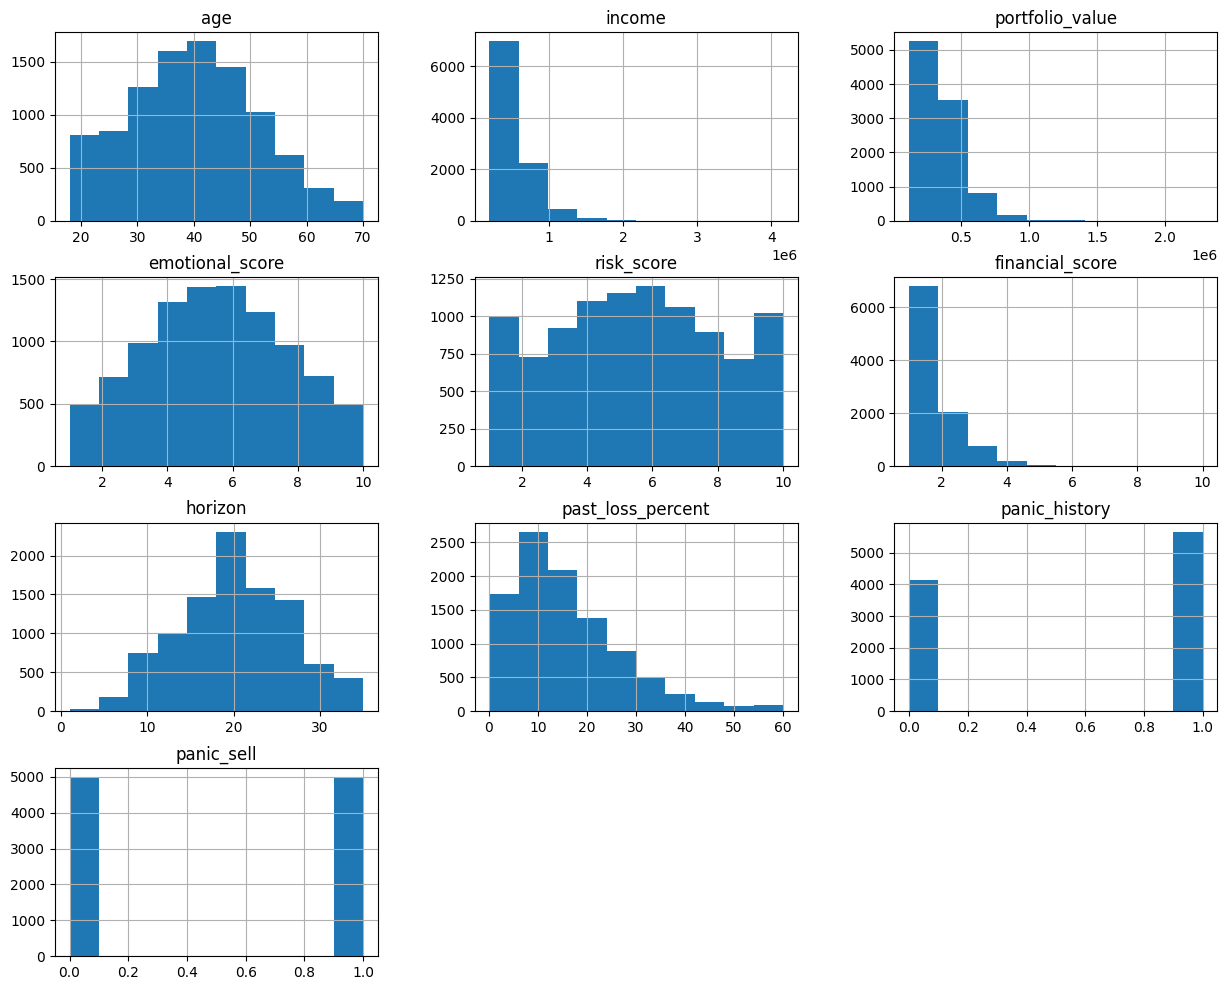

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

df.hist(figsize=(15,12))
plt.show()

Outliers

<Axes: xlabel='income'>

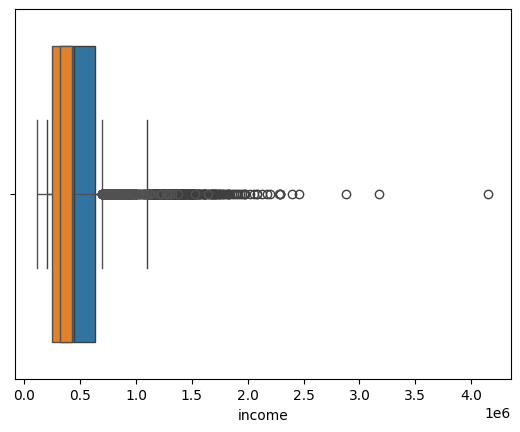

In [28]:
sns.boxplot(x=df['income'])
sns.boxplot(x=df['portfolio_value'])

Correlation Heatmap

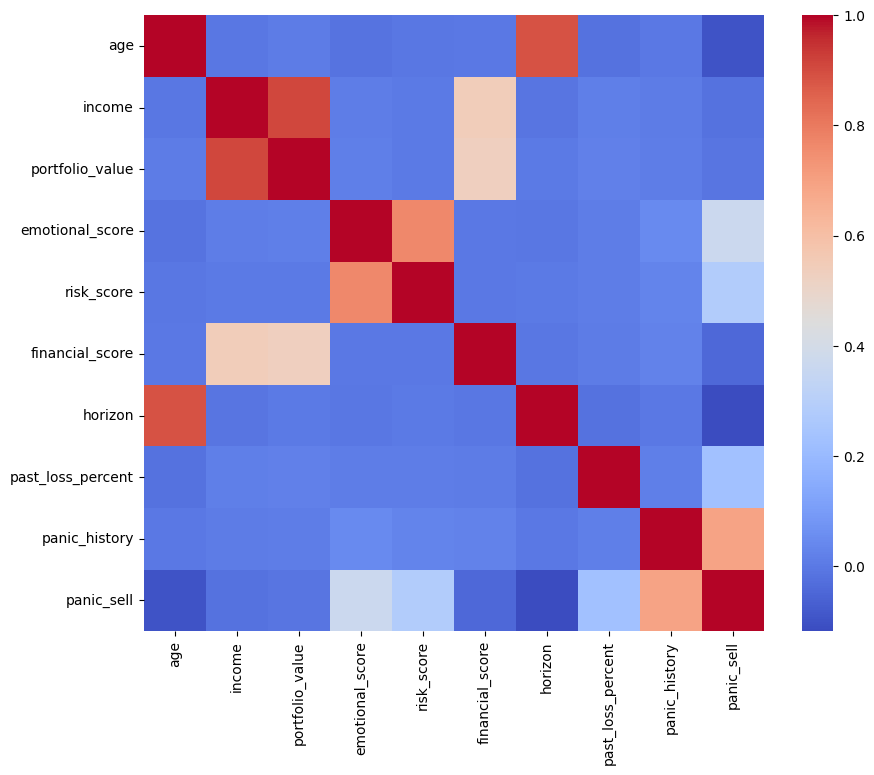

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.show()

<Axes: xlabel='panic_sell', ylabel='emotional_score'>

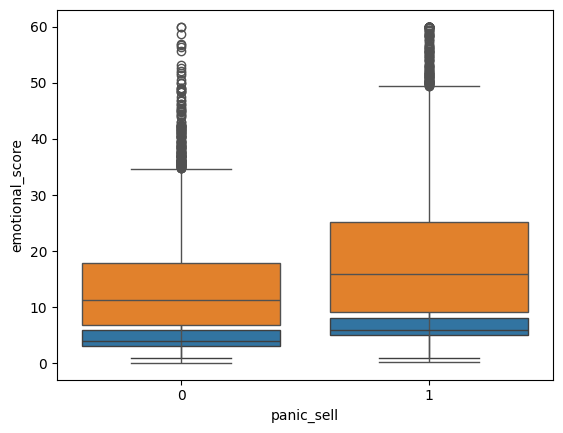

In [30]:
sns.boxplot(x='panic_sell', y='emotional_score', data=df)
sns.boxplot(x='panic_sell', y='past_loss_percent', data=df)

In [31]:
from sklearn.impute import SimpleImputer

num_cols = df.columns.drop("panic_sell")

imputer = SimpleImputer(strategy="median")
df[num_cols] = imputer.fit_transform(df[num_cols])

In [32]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

Feature Engineering

In [33]:
df['income_portfolio_ratio'] = df['income'] / (df['portfolio_value'] + 1)

In [34]:
df['emotion_loss_interaction'] = df['emotional_score'] * df['past_loss_percent']

In [35]:
df['stability_index'] = df['financial_score'] * df['horizon']

Feature Scaling

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

Train-Test Split

In [37]:
from sklearn.model_selection import train_test_split

X = df.drop("panic_sell", axis=1)
y = df["panic_sell"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)
prob_log = log_model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, prob_log))

ROC-AUC: 0.97133


In [39]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [41]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [42]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, rf_model.predict(X_test))

array([[900, 100],
       [ 88, 912]])

In [43]:
from sklearn.metrics import roc_curve

In [44]:
from sklearn.metrics import precision_recall_curve

In [45]:
from sklearn.metrics import f1_score

In [46]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

 Hyperparameter Tuning

In [47]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators':[100,200,300],
    'max_depth':[4,6,8,None]
}

search = RandomizedSearchCV(
    RandomForestClassifier(),
    params,
    cv=5,
    scoring='roc_auc'
)

search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to

In [48]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5)
scores = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')
print(scores.mean())

0.9660094000000001


In [49]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances)

panic_history               0.463316
emotional_score             0.100563
past_loss_percent           0.088634
emotion_loss_interaction    0.081019
age                         0.046150
risk_score                  0.045349
horizon                     0.038926
portfolio_value             0.038519
income_portfolio_ratio      0.036614
income                      0.036139
stability_index             0.016753
financial_score             0.008017
dtype: float64


In [50]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    brier_score_loss
)

import pandas as pd

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    cm = confusion_matrix(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    brier = brier_score_loss(y_test, y_prob)

    print("\n" + "="*60)
    print(f"MODEL: {name}")
    print("="*60)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print(f"ROC-AUC Score: {roc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Brier Score: {brier:.4f}")

    results.append([name, roc, f1, precision, recall, brier])

# Summary Table
results_df = pd.DataFrame(
    results,
    columns=["Model", "ROC-AUC", "F1 Score", "Precision", "Recall", "Brier Score"]
)

print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(results_df.sort_values(by="ROC-AUC", ascending=False))


MODEL: Logistic Regression

Confusion Matrix:
[[906  94]
 [ 88 912]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1000
           1       0.91      0.91      0.91      1000

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000

ROC-AUC Score: 0.9713
F1 Score: 0.9093
Precision: 0.9066
Recall: 0.9120
Brier Score: 0.0656

MODEL: Decision Tree

Confusion Matrix:
[[902  98]
 [128 872]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      1000
           1       0.90      0.87      0.89      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

ROC-AUC Score: 0.9562
F1 Score: 0.8853
Precision: 0.8990
Recall: 0.8720


| Model               | ROC-AUC | F1      | Recall | Brier  |
| ------------------- | ------- | ------- | ------ | ------ |
| Logistic Regression | Medium  | Medium  | Medium | Medium |
| Decision Tree       | Lower   | Lower   | Lower  | Worse  |
| Random Forest       | High    | High    | High   | Good   |
| Gradient Boosting   | Highest | Highest | High   | Best   |


best choice is random forest bcoz it is highly stable less overfit easier to deploy 

gradient boosting is best but it is more sensitive to tuning can overfit if not tuned well


In [51]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

# Load dataset
df = pd.read_csv("synthetic_financial_behavior_dataset.csv")

# Features & target
X = df.drop("panic_sell", axis=1)
y = df["panic_sell"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Identify numeric columns
numeric_features = X.columns

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

# Full pipeline (Preprocessing + Model)
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ))
])

# Train model
model_pipeline.fit(X_train, y_train)

# Save as .pkl file
joblib.dump(model_pipeline, "panic_prediction_model.pkl")

print("✅ Model saved successfully as panic_prediction_model.pkl")

✅ Model saved successfully as panic_prediction_model.pkl


In [52]:
import sklearn
print(sklearn.__version__)

1.8.0
